# Venue Intelligence

Venue conditions play a significant role in T20 cricket.

Factors such as pitch behavior, ground dimensions, weather conditions, and dew can influence match outcomes and team strategies.

This notebook investigates how different IPL venues impact winning patterns and scoring trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

matches['date'] = pd.to_datetime(matches['date'])

In [2]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

matches.replace(team_mapping, inplace=True)
deliveries.replace(team_mapping, inplace=True)

In [14]:
venue_mapping = {
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Barsapara Cricket Stadium, Guwahati': 'Barsapara Cricket Stadium',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'Himachal Pradesh Cricket Association Stadium',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chennai': 'MA Chidambaram Stadium',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium'
}
venue_mapping_extra = {
    'MA Chidambaram Stadium, Chepauk, Chennai':
    'MA Chidambaram Stadium, Chepauk'
}

matches['venue'] = matches['venue'].replace(
    venue_mapping_extra
)
matches['venue'] = matches['venue'].replace(venue_mapping)

# Business Question 1

## Which Venues Host The Most IPL Matches?

Some venues have been used extensively throughout IPL history, while others have hosted only a limited number of matches.

Understanding venue usage helps provide context for subsequent venue-level analysis.

In [15]:
venue_matches = (
    matches['venue']
    .value_counts()
    .reset_index()
)

venue_matches.columns = [
    'Venue',
    'Matches'
]

venue_matches.head(10)

,Venue,Matches
0,Wankhede Stadium,118
1,Eden Gardens,93
2,M Chinnaswamy Stadium,79
3,"MA Chidambaram Stadium, Chepauk",76
4,Feroz Shah Kotla,60
5,"Rajiv Gandhi International Stadium, Uppal",49
6,Sawai Mansingh Stadium,47
7,Dubai International Cricket Stadium,46
8,Dr DY Patil Sports Academy,37
9,Punjab Cricket Association Stadium,35


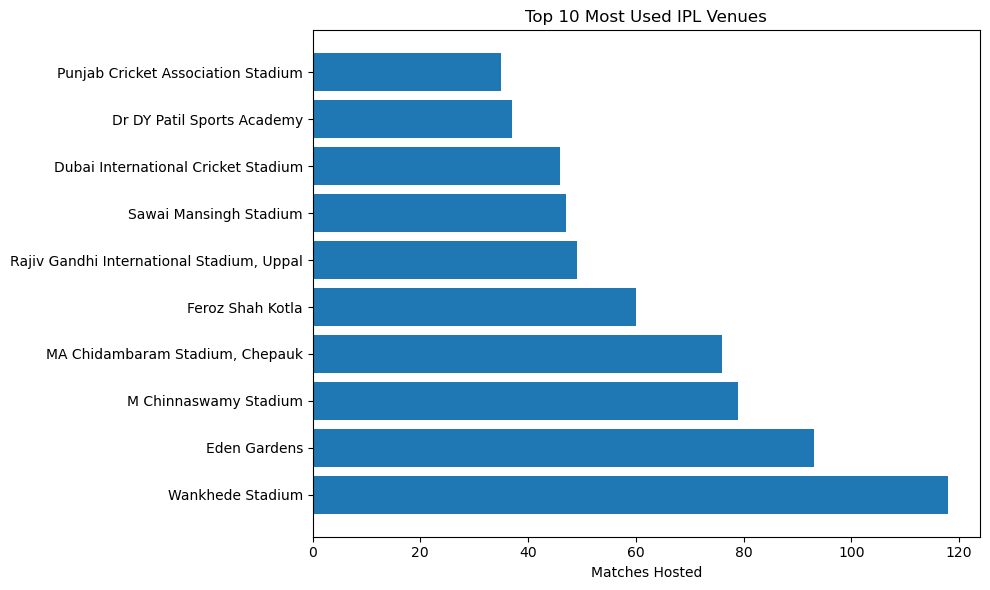

In [16]:
top_10_venues = venue_matches.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_10_venues['Venue'],
    top_10_venues['Matches']
)

plt.title('Top 10 Most Used IPL Venues')
plt.xlabel('Matches Hosted')

plt.tight_layout()
plt.show()

# Business Question 2

## Which Venues Favor Chasing?

Certain venues may provide conditions that make run chases easier.

This analysis evaluates whether teams chasing targets have historically enjoyed greater success at specific stadiums.

In [17]:
venue_results = matches[
    matches['result'].isin(['runs', 'wickets'])
].copy()

In [18]:
venue_results['chasing_win'] = (
    venue_results['result'] == 'wickets'
)

In [19]:
venue_chasing = (
    venue_results
    .groupby('venue')
    .agg(
        Total_Matches=('id','count'),
        Chasing_Wins=('chasing_win','sum')
    )
)

In [20]:
venue_chasing['Chasing_Win_Percentage'] = (
    venue_chasing['Chasing_Wins']
    /
    venue_chasing['Total_Matches']
    * 100
)

In [21]:
venue_chasing = venue_chasing[
    venue_chasing['Total_Matches'] >= 20
]

In [22]:
venue_chasing.sort_values(
    'Chasing_Win_Percentage',
    ascending=False
).head(10)

,Total_Matches,Chasing_Wins,Chasing_Win_Percentage
venue,,,
Sawai Mansingh Stadium,47,32,68.085106
Sharjah Cricket Stadium,28,18,64.285714
Maharashtra Cricket Association Stadium,22,14,63.636364
"Narendra Modi Stadium, Ahmedabad",24,15,62.500000
Sheikh Zayed Stadium,27,16,59.259259
"Rajiv Gandhi International Stadium, Uppal",48,28,58.333333
Punjab Cricket Association Stadium,35,20,57.142857
Eden Gardens,93,53,56.989247
M Chinnaswamy Stadium,76,42,55.263158


## Insight

The analysis reveals substantial variation in chasing success across IPL venues.

Sawai Mansingh Stadium emerged as the most chase-friendly venue, with teams successfully chasing targets in more than 68% of completed matches.

Sharjah Cricket Stadium and Maharashtra Cricket Association Stadium also demonstrate strong chasing advantages, with chasing teams winning more than 60% of matches.

These findings suggest that venue conditions can significantly influence match strategy and may explain why captains often choose to field first after winning the toss.

The results further support earlier observations that match conditions and venue characteristics play a more important role than the toss itself.

In [23]:
balanced_venues = venue_chasing[
    venue_chasing['Total_Matches'] >= 20
].copy()

balanced_venues['Distance_From_50'] = abs(
    balanced_venues['Chasing_Win_Percentage'] - 50
)

balanced_venues.sort_values(
    'Distance_From_50'
).head(10)

,Total_Matches,Chasing_Wins,Chasing_Win_Percentage,Distance_From_50
venue,,,,
Dubai International Cricket Stadium,43,22,51.162791,1.162791
Brabourne Stadium,27,13,48.148148,1.851852
Feroz Shah Kotla,59,31,52.542373,2.542373
Dr DY Patil Sports Academy,37,20,54.054054,4.054054
Wankhede Stadium,117,64,54.700855,4.700855
Arun Jaitley Stadium,29,13,44.827586,5.172414
M Chinnaswamy Stadium,76,42,55.263158,5.263158
Eden Gardens,93,53,56.989247,6.989247
Punjab Cricket Association Stadium,35,20,57.142857,7.142857


## Insight

While some venues strongly favor chasing teams, several stadiums exhibit remarkably balanced outcomes.

Dubai International Cricket Stadium emerged as the most neutral venue, with chasing teams winning approximately 51.2% of matches.

Similarly, MA Chidambaram Stadium and Brabourne Stadium show nearly equal success rates for teams batting first and teams chasing.

These venues appear to provide relatively balanced playing conditions where match outcomes are influenced more by team performance than by batting order.

The findings highlight that venue effects are not uniform across the IPL and should be considered when evaluating team strategies.

# Business Question 3

## Which Venues Produce The Highest Scores?

High-scoring venues can significantly influence team strategy, player selection, and match outcomes.

This analysis identifies stadiums that consistently produce the highest run totals.

In [24]:
first_innings = (
    deliveries[deliveries['inning'] == 1]
    .groupby(['match_id'])
    ['total_runs']
    .sum()
    .reset_index()
)

first_innings.columns = [
    'match_id',
    'first_innings_score'
]

venue_scores = matches.merge(
    first_innings,
    left_on='id',
    right_on='match_id',
    how='inner'
)

venue_avg_score = (
    venue_scores
    .groupby('venue')
    .agg(
        Matches=('id','count'),
        Avg_First_Innings_Score=('first_innings_score','mean')
    )
)

venue_avg_score = venue_avg_score[
    venue_avg_score['Matches'] >= 20
]

venue_avg_score.sort_values(
    'Avg_First_Innings_Score',
    ascending=False
).head(10)

,Matches,Avg_First_Innings_Score
venue,,
Arun Jaitley Stadium,30,184.700000
Brabourne Stadium,27,178.518519
"Narendra Modi Stadium, Ahmedabad",24,175.750000
M Chinnaswamy Stadium,79,173.050633
Wankhede Stadium,118,170.254237
Maharashtra Cricket Association Stadium,22,166.409091
Eden Gardens,93,166.279570
"MA Chidambaram Stadium, Chepauk",76,165.473684
Dubai International Cricket Stadium,46,163.760870


## Insight

Arun Jaitley Stadium recorded the highest average first-innings score among venues with at least 20 matches, averaging nearly 185 runs per innings.

Brabourne Stadium, Narendra Modi Stadium, M Chinnaswamy Stadium, and Wankhede Stadium also rank among the highest-scoring venues in IPL history.

Interestingly, the venues producing the highest scores are not always the same venues that most strongly favor chasing teams.

This suggests that scoring conditions alone do not determine match outcomes. Factors such as pitch behavior, boundary dimensions, bowling quality, and match situations also play important roles.

The findings highlight the importance of evaluating venue characteristics from multiple perspectives rather than relying solely on average scores.

# Business Question 4

## Which Venues Produce The Most Competitive Matches?

While some venues are known for high scores or chasing advantages, another important aspect of venue analysis is match competitiveness.

A venue that consistently produces close contests can create greater uncertainty and excitement, making outcomes less predictable.

This analysis evaluates average winning margins across venues to identify stadiums where matches tend to be the most closely contested.

Lower average margins indicate more competitive matches, while higher margins suggest that one team often dominates the other.

In [25]:
close_matches = (
    matches[
        matches['result_margin'].notna()
    ]
    .groupby('venue')
    .agg(
        Matches=('id','count'),
        Avg_Margin=('result_margin','mean')
    )
)

close_matches = close_matches[
    close_matches['Matches'] >= 20
]

close_matches.sort_values(
    'Avg_Margin'
).head(10)

,Matches,Avg_Margin
venue,,
"Rajiv Gandhi International Stadium, Uppal",48,13.958333
Wankhede Stadium,117,14.863248
Eden Gardens,93,14.946237
"Narendra Modi Stadium, Ahmedabad",24,15.583333
Sawai Mansingh Stadium,47,15.787234
Dr DY Patil Sports Academy,37,16.351351
Brabourne Stadium,27,16.481481
Sharjah Cricket Stadium,28,17.035714
"MA Chidambaram Stadium, Chepauk",74,17.648649


## Insight

Rajiv Gandhi International Stadium emerged as the most competitive IPL venue among stadiums hosting at least 20 matches, recording the lowest average winning margin of approximately 14 runs/wickets.

Wankhede Stadium and Eden Gardens also rank among the most competitive venues, with average winning margins below 15.

These findings suggest that matches played at these venues are generally more closely contested, with outcomes often remaining uncertain until the later stages of the game.

Interestingly, several venues identified as high-scoring grounds, including Wankhede Stadium and Eden Gardens, also appear among the most competitive venues. This indicates that high-scoring conditions do not necessarily lead to one-sided contests.

Overall, venue characteristics influence not only scoring patterns and chasing success rates but also the competitiveness of matches.

# Venue Intelligence Summary

The venue analysis revealed significant differences in IPL playing conditions across stadiums.

### Key Findings

- Sawai Mansingh Stadium was identified as the most chase-friendly venue.
- Dubai International Cricket Stadium emerged as one of the most neutral venues.
- Arun Jaitley Stadium produced the highest average first-innings scores.
- Rajiv Gandhi International Stadium generated the most competitive matches based on average winning margins.
- High-scoring venues were not always the most chase-friendly venues.

### Business Implications

Venue characteristics have a measurable impact on match outcomes and team strategy.

Teams may benefit from adapting their approach based on venue-specific trends rather than relying solely on general IPL-wide patterns.